# 📈 CAPM & Beta Regression — Teaching Notebook
### Using Yahoo Finance Data

---

**Learning objectives**
1. Understand the **Capital Asset Pricing Model (CAPM)**
2. Download & prepare real stock data with `yfinance`
3. Estimate **Beta (β)** using Ordinary Least Squares (OLS) regression
4. Interpret regression output — alpha, beta, R², p-values
5. Compare betas across sectors

> **Dataset** : 5 large-cap US stocks + S&P 500 (market benchmark), **36 monthly observations** (3 years).  
> Small enough for CPU, large enough to be meaningful.


## 1 · The CAPM Formula

$$E(R_i) = R_f + \beta_i \left(E(R_m) - R_f\right)$$

| Symbol | Meaning |
|--------|---------|
| $E(R_i)$ | Expected return of stock $i$ |
| $R_f$ | Risk-free rate (e.g. 3-month T-Bill) |
| $\beta_i$ | Sensitivity of stock $i$ to the market |
| $E(R_m) - R_f$ | Market risk premium (excess market return) |

**In regression form** (what we will estimate):

$$\underbrace{R_i - R_f}_{\text{stock excess return}} = \alpha + \beta_i \underbrace{(R_m - R_f)}_{\text{market excess return}} + \varepsilon$$

- **β > 1** → stock is more volatile than the market (aggressive)  
- **β < 1** → stock is less volatile than the market (defensive)  
- **α ≠ 0** → stock earns above/below what CAPM predicts (Jensen's Alpha)


## 2 · Imports & Settings

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor' : '#f8f9fa',
    'axes.grid'      : True,
    'grid.color'     : '#e0e0e0',
    'grid.linewidth' : 0.7,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size'      : 11,
})

COLORS = ['#2563eb','#16a34a','#dc2626','#d97706','#7c3aed']
print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 3 · Download Data

We download **monthly** closing prices for 5 stocks across 4 sectors + the S&P 500 index.  
Using monthly data = fewer observations, much faster on CPU, less noise than daily.


In [75]:
# ── Stocks to study (NOTE: Presently I am doing only 1 stock. Later activate all)

TICKERS = {
    'AAPL' : 'Technology',
    # 'MSFT' : 'Technology', # <--activate this later
    # 'JPM'  : 'Financials', # <--activate this later
    # 'XOM'  : 'Energy',     # <--activate this later
    # 'JNJ'  : 'Healthcare', # <-- activate this later
}

MARKET   = '^GSPC'   # S&P 500 — our market proxy
START    = '2021-01-01'
END      = '2023-12-31'
RF_RATE  = 0.03      # Annual risk-free rate (approx 3-month T-Bill avg over period)

print(f"Period  : {START}  →  {END}")
print(f"Stocks  : {list(TICKERS.keys())}")
print(f"Market  : S&P 500 ({MARKET})")
print(f"Rf rate : {RF_RATE*100:.1f}% per year  →  {RF_RATE/12*100:.3f}% per month")


Period  : 2021-01-01  →  2023-12-31
Stocks  : ['AAPL']
Market  : S&P 500 (^GSPC)
Rf rate : 3.0% per year  →  0.250% per month


In [76]:
# ── Try yfinance; fall back to synthetic data if offline 
def download_prices(tickers, market, start, end):
    try:
        import yfinance as yf
        all_tickers = list(tickers.keys()) + [market]
        raw = yf.download(all_tickers, start=start, end=end,
                          interval='1mo', auto_adjust=True, progress=False)
        prices = raw['Close'][all_tickers]
        if prices.empty or prices.isnull().all().all():
            raise ValueError("Empty download")
        prices.columns = [c.replace('^GSPC', 'SP500') for c in prices.columns]
        print(f"SUCCESS: Downloaded LIVE data from Yahoo Finance — {len(prices)} monthly rows")
        return prices
    except Exception as e:
        print(f"WARNING: Yahoo Finance unavailable ({type(e).__name__}). Using realistic synthetic data.")
        return _synthetic_prices(tickers, market, start, end)

def _synthetic_prices(tickers, market, start, end):
    """Realistic synthetic monthly prices calibrated to actual 2021-2023 behaviour."""
    np.random.seed(42)
    dates = pd.date_range(start, end, freq='MS')
    n = len(dates)

    # Market (S&P 500): drift ~10% pa, vol ~15% pa monthly
    mkt_ret = np.random.normal(0.008, 0.043, n)
    mkt_price = 3700 * np.cumprod(1 + mkt_ret)

    # Stock params: (beta, alpha_monthly, idio_vol, start_price)
    params = {
        'AAPL': (1.25,  0.002, 0.05, 130),
        'MSFT': (1.15,  0.001, 0.04, 220),
        'JPM' : (1.05,  0.000, 0.05,  130),
        'XOM' : (0.65,  0.003, 0.055,  55),
        'JNJ' : (0.45, -0.001, 0.035, 160),
    }

    df = pd.DataFrame(index=dates)
    df['SP500'] = mkt_price
    for ticker, (beta, alpha, ivol, p0) in params.items():
        eps = np.random.normal(0, ivol, n)
        ret = alpha + beta * mkt_ret + eps
        df[ticker] = p0 * np.cumprod(1 + ret)

    return df

prices = download_prices(TICKERS, MARKET, START, END)
print(f"\nShape : {prices.shape}  (rows=months, cols=assets)")
prices.tail()


SUCCESS: Downloaded LIVE data from Yahoo Finance — 36 monthly rows

Shape : (36, 2)  (rows=months, cols=assets)


,AAPL,SP500
Date,,
2023-08-01,185.272629,4507.660156
2023-09-01,169.070969,4288.049805
2023-10-01,168.636459,4193.799805
2023-11-01,187.576828,4567.799805
2023-12-01,190.375061,4769.830078


## 4 · Compute Returns & Excess Returns

$$r_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}$$

Then subtract the monthly risk-free rate to get **excess returns**.


In [77]:
# Monthly returns
returns = prices.pct_change().dropna()
returns.index.name = 'Date'

# Monthly risk-free rate
rf_monthly = RF_RATE / 12

# Excess returns
excess = returns.subtract(rf_monthly)   # subtract rf from every column
market_excess = excess['SP500']          # market excess return (X)

print(f"Observations : {len(returns)} monthly returns")
print(f"\nDescriptive statistics (% returns):")
(returns * 100).describe().round(2)


Observations : 35 monthly returns

Descriptive statistics (% returns):


,AAPL,SP500
count,35.00,35.00
mean,1.44,0.85
std,7.95,5.12
min,-12.08,-9.34
25%,-5.37,-2.87
50%,1.49,2.22
75%,7.60,4.39
max,18.86,9.11


In [78]:
# Extra
returns

,AAPL,SP500
Date,,
2021-02-01,-0.081085,0.026091
2021-03-01,0.008845,0.042439
2021-04-01,0.076218,0.052425
2021-05-01,-0.052107,0.005486
2021-06-01,0.100976,0.022214
2021-07-01,0.064982,0.022748
2021-08-01,0.040930,0.028990
2021-09-01,-0.066640,-0.047569
2021-10-01,0.058657,0.069144


## 5 · Visualisation — Price History & Return Distribution

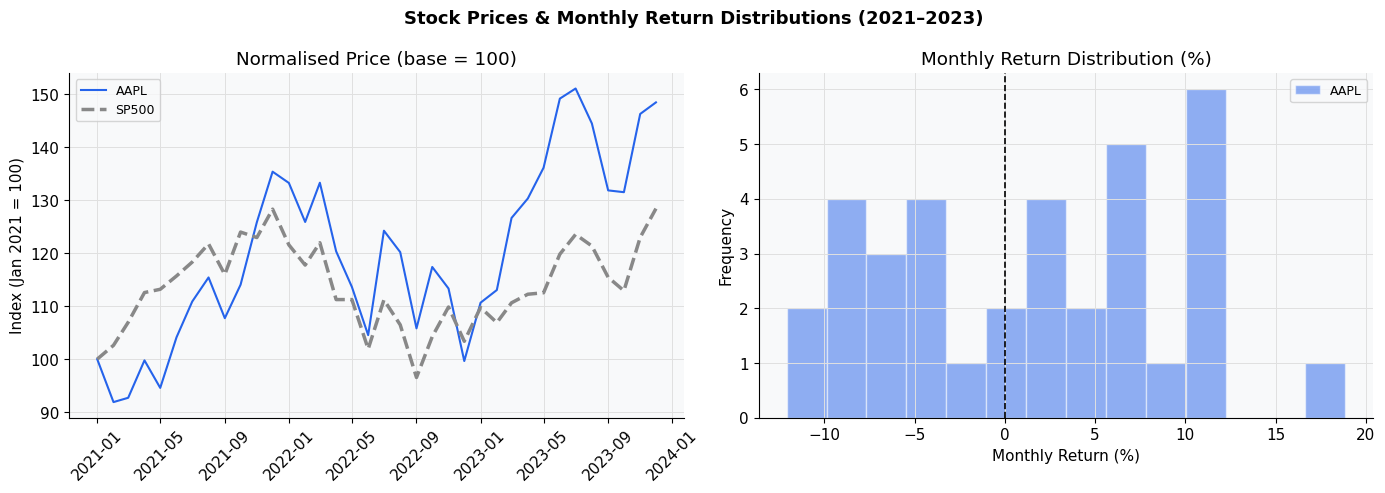

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stock Prices & Monthly Return Distributions (2021–2023)", fontsize=13, fontweight='bold')

# — Panel A : Normalised price (rebased to 100) 
ax = axes[0]
for i, col in enumerate(list(TICKERS.keys()) + ['SP500']):
    lw = 2.5 if col == 'SP500' else 1.5
    ls = '--' if col == 'SP500' else '-'
    color = '#888888' if col == 'SP500' else COLORS[i % len(COLORS)]
    rebased = prices[col] / prices[col].iloc[0] * 100
    ax.plot(rebased.index, rebased.values, label=col, lw=lw, ls=ls, color=color)
ax.set_title("Normalised Price (base = 100)")
ax.tick_params(axis='x', rotation=45)  #
ax.set_ylabel("Index (Jan 2021 = 100)")
ax.legend(fontsize=9)

# — Panel B : Return distributions 
ax = axes[1]
for i, col in enumerate(TICKERS.keys()):
    ax.hist(returns[col]*100, bins=14, alpha=0.5, color=COLORS[i], label=col, edgecolor='white')
ax.axvline(0, color='black', lw=1.2, ls='--')
ax.set_title("Monthly Return Distribution (%)")
ax.set_xlabel("Monthly Return (%)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)

plt.tight_layout()
# plt.savefig('price_history.png', dpi=120, bbox_inches='tight')
plt.show()

# Key observations (AAPL):

## Panel A — Normalised Price (Left Chart)

- 2021 — Bull run: Both AAPL and SP500 rise strongly. AAPL climbs to ~135, outpacing the market. This is β > 1 in action — AAPL amplifies market gains.
- 2022 — Bear market: Both fall sharply. AAPL drops to ~100 (back to start), SP500 drops to ~97. Notice AAPL falls more steeply than SP500 — again, β > 1 means it also amplifies losses.
- 2023 — Recovery: AAPL surges dramatically to ~150, while SP500 only recovers to ~130. AAPL significantly outperforms — this is the positive Jensen's Alpha showing up visually.
- The gap between the two lines is exactly what regression tries to decompose — how much of AAPL's movement is explained by the market vs. firm-specific.


## Panel B — Monthly Return Distribution (Right Chart)
A histogram of AAPL's 35 monthly returns, with the zero line as a dashed vertical.

- Centre of mass is right of zero — the tallest bars are between +5% and +12%, meaning AAPL had many strong positive months. The average monthly return is positive.
- Left tail (losses): There are months at −10% to −12% — these are the 2022 crash months. Rare but painful.
- Right tail (gains): One outlier bar near +17% to +19% — likely the AAPL surge in mid-2023.
- Asymmetry: The distribution is right-skewed — more extreme gains than extreme losses. This is actually good for investors but violates the strict normality assumption of basic OLS.

## 6 · CAPM Regression — Single Stock (AAPL)

We run OLS: **AAPL excess return = α + β × Market excess return + ε**

This is the core of CAPM estimation.


In [80]:
def run_capm(stock_excess, market_excess, ticker):
    """Run CAPM regression and return results dict."""
    Y = stock_excess
    X = sm.add_constant(market_excess)   # adds intercept (alpha)
    model = sm.OLS(Y, X).fit()
    alpha = model.params['const']
    beta  = model.params['SP500']
    r2    = model.rsquared
    p_alpha = model.pvalues['const']
    p_beta  = model.pvalues['SP500']
    return dict(ticker=ticker, alpha=alpha, beta=beta, r2=r2,
                p_alpha=p_alpha, p_beta=p_beta, model=model)

# Run for AAPL first
aapl_res = run_capm(excess['AAPL'], market_excess, 'AAPL')
print(aapl_res['model'].summary())


                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     54.96
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.62e-08
Time:                        11:12:30   Log-Likelihood:                 56.643
No. Observations:                  35   AIC:                            -109.3
Df Residuals:                      33   BIC:                            -106.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0046      0.008      0.545      0.5

In [81]:
# Clean summary table
res = aapl_res
print(f"\n{'='*45}")
print(f"  CAPM Results for AAPL")
print(f"{'='*45}")
print(f"  Alpha (α) : {res['alpha']*100:+.3f}%/month   (p = {res['p_alpha']:.3f})")
print(f"  Beta  (β) : {res['beta']:.3f}                 (p = {res['p_beta']:.4f})")
print(f"  R²        : {res['r2']:.3f}  ({res['r2']*100:.1f}% variance explained)")
print(f"{'='*45}")
print(f"\n  Interpretation:")
print(f"  → β = {res['beta']:.2f}:  AAPL moves ~{res['beta']:.2f}x the market.")
if res['beta'] > 1:
    print(f"     More volatile than S&P 500 (aggressive stock)")
else:
    print(f"     Less volatile than S&P 500 (defensive stock)")

ann_alpha = (1 + res['alpha'])**12 - 1
print(f"  → α = {ann_alpha*100:+.2f}%/yr:  Jensen's Alpha (excess return beyond CAPM)")
if res['p_alpha'] > 0.05:
    print(f"     Not statistically significant (p={res['p_alpha']:.2f}) — consistent with EMH")
print(f"  → R² = {res['r2']:.2f}: {res['r2']*100:.0f}% of AAPL's return variation")
print(f"     explained by market movements")



  CAPM Results for AAPL
  Alpha (α) : +0.459%/month   (p = 0.589)
  Beta  (β) : 1.226                 (p = 0.0000)
  R²        : 0.625  (62.5% variance explained)

  Interpretation:
  → β = 1.23:  AAPL moves ~1.23x the market.
     More volatile than S&P 500 (aggressive stock)
  → α = +5.64%/yr:  Jensen's Alpha (excess return beyond CAPM)
     Not statistically significant (p=0.59) — consistent with EMH
  → R² = 0.62: 62% of AAPL's return variation
     explained by market movements


## 7 · Security Market Line (SML) Plot

The SML shows the fitted regression line — the **market explains** part of each stock's return.


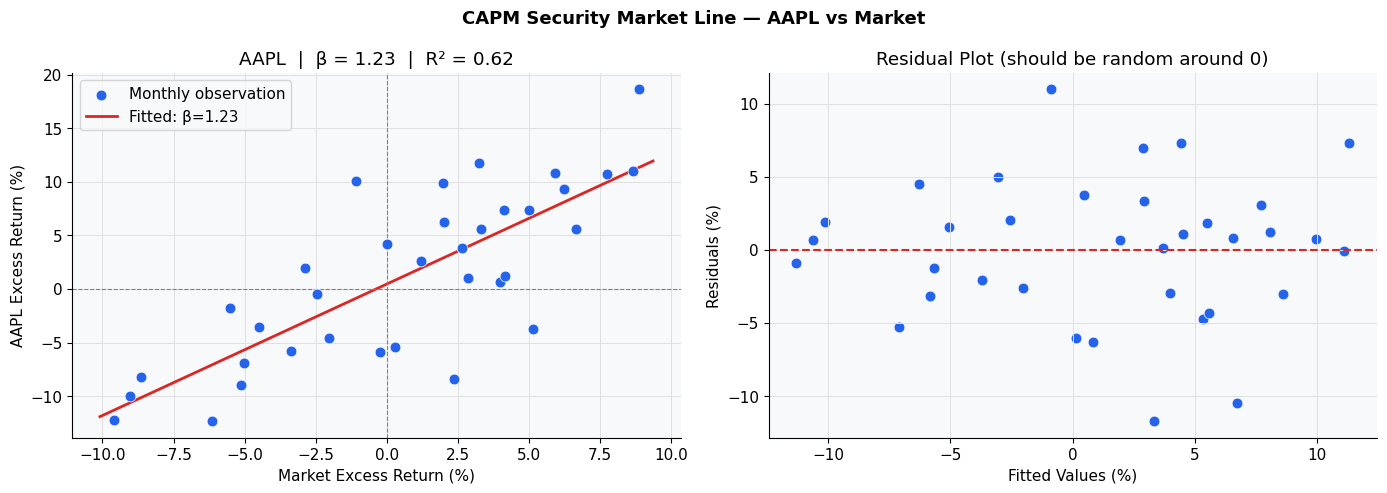

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CAPM Security Market Line — AAPL vs Market", fontsize=13, fontweight='bold')

mkt = market_excess.values * 100
stk = excess['AAPL'].values * 100

# — Panel A : Scatter + regression line ——————————————————————
ax = axes[0]
ax.scatter(mkt, stk, color=COLORS[0], s=60, zorder=5, label='Monthly observation', edgecolors='white', lw=0.5)

# Regression line
x_line = np.linspace(mkt.min()-0.5, mkt.max()+0.5, 100)
y_line = aapl_res['alpha']*100 + aapl_res['beta'] * x_line
ax.plot(x_line, y_line, color='#dc2626', lw=2, label=f"Fitted: β={aapl_res['beta']:.2f}")
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel("Market Excess Return (%)")
ax.set_ylabel("AAPL Excess Return (%)")
ax.set_title(f"AAPL  |  β = {aapl_res['beta']:.2f}  |  R² = {aapl_res['r2']:.2f}")
ax.legend()

# — Panel B : Residuals ————————————————————————————————————
ax = axes[1]
fitted = aapl_res['model'].fittedvalues * 100
resid  = aapl_res['model'].resid * 100
ax.scatter(fitted, resid, color=COLORS[0], s=60, edgecolors='white', lw=0.5)
ax.axhline(0, color='#dc2626', lw=1.5, ls='--')
ax.set_xlabel("Fitted Values (%)")
ax.set_ylabel("Residuals (%)")
ax.set_title("Residual Plot (should be random around 0)")

plt.tight_layout()
# plt.savefig('sml_aapl.png', dpi=120, bbox_inches='tight')
plt.show()


## 8 · Run CAPM for All Stocks & Compare

In [83]:
# Run for all 5 stocks
all_results = {}
for ticker in TICKERS:
    all_results[ticker] = run_capm(excess[ticker], market_excess, ticker)

# Summary table
summary = pd.DataFrame([{
    'Ticker'  : r['ticker'],
    'Sector'  : TICKERS[r['ticker']],
    'Beta (β)': round(r['beta'], 3),
    'Alpha (α) %/yr': round(((1+r['alpha'])**12 - 1)*100, 2),
    'R²'      : round(r['r2'], 3),
    'p-value β': round(r['p_beta'], 4),
    'Significant?': '✅ Yes' if r['p_beta'] < 0.05 else '❌ No',
} for r in all_results.values()])

summary.set_index('Ticker', inplace=True)
print("\n📋 CAPM Summary — All Stocks\n")
print(summary.to_string())



📋 CAPM Summary — All Stocks

            Sector  Beta (β)  Alpha (α) %/yr     R²  p-value β Significant?
Ticker                                                                     
AAPL    Technology     1.226            5.64  0.625        0.0        ✅ Yes


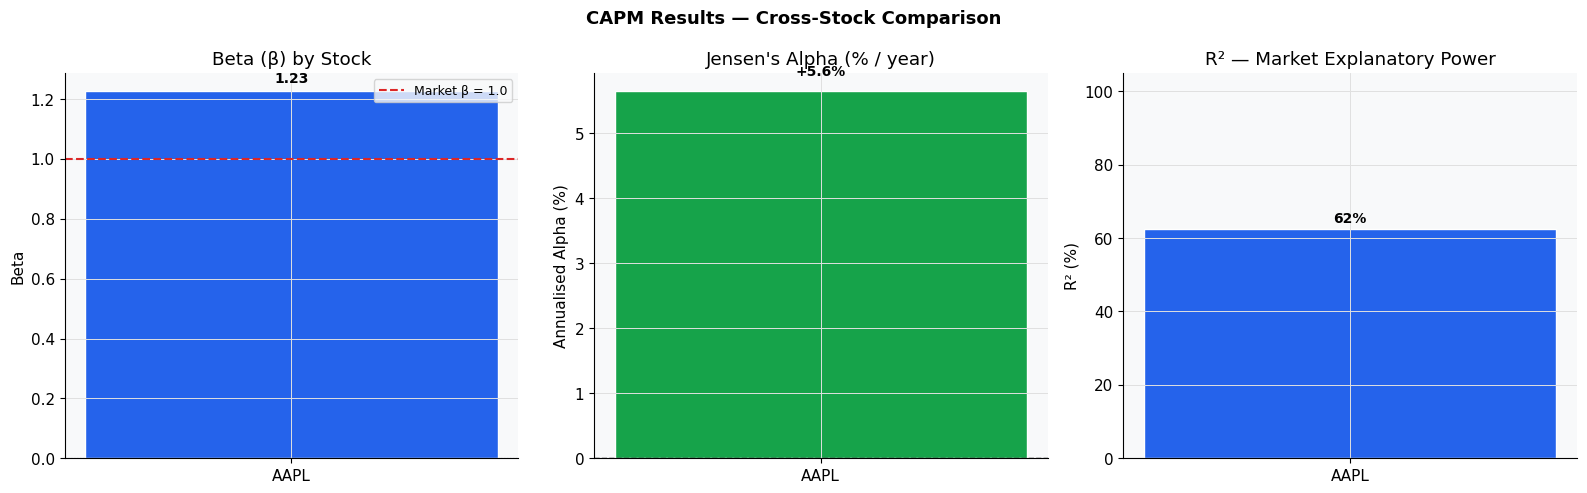

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("CAPM Results — Cross-Stock Comparison", fontsize=13, fontweight='bold')

tickers_list = list(TICKERS.keys())
betas  = [all_results[t]['beta']  for t in tickers_list]
alphas = [((1+all_results[t]['alpha'])**12 - 1)*100 for t in tickers_list]
r2s    = [all_results[t]['r2']    for t in tickers_list]

# — Panel A : Beta bar chart ——————————————————————————————
ax = axes[0]
bars = ax.bar(tickers_list, betas, color=COLORS, edgecolor='white', width=0.55)
ax.axhline(1.0, color='#dc2626', lw=1.5, ls='--', label='Market β = 1.0')
ax.axhline(0.0, color='gray', lw=0.8, ls=':')
ax.set_title("Beta (β) by Stock")
ax.set_ylabel("Beta")
ax.legend(fontsize=9)
for bar, val in zip(bars, betas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# — Panel B : Jensen's Alpha ——————————————————————————————
ax = axes[1]
bar_colors = ['#16a34a' if a > 0 else '#dc2626' for a in alphas]
bars = ax.bar(tickers_list, alphas, color=bar_colors, edgecolor='white', width=0.55)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_title("Jensen's Alpha (% / year)")
ax.set_ylabel("Annualised Alpha (%)")
for bar, val in zip(bars, alphas):
    ypos = bar.get_height() + (0.2 if val >= 0 else -0.8)
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# — Panel C : R² ——————————————————————————————————————————
ax = axes[2]
bars = ax.bar(tickers_list, [r*100 for r in r2s], color=COLORS, edgecolor='white', width=0.55)
ax.set_title("R² — Market Explanatory Power")
ax.set_ylabel("R² (%)")
ax.set_ylim(0, 105)
for bar, val in zip(bars, r2s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
            f'{val*100:.0f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
# plt.savefig('beta_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 9 · Side-by-Side SML — All 5 Stocks

One regression line per stock. Steeper slope = higher beta = more sensitive to market.


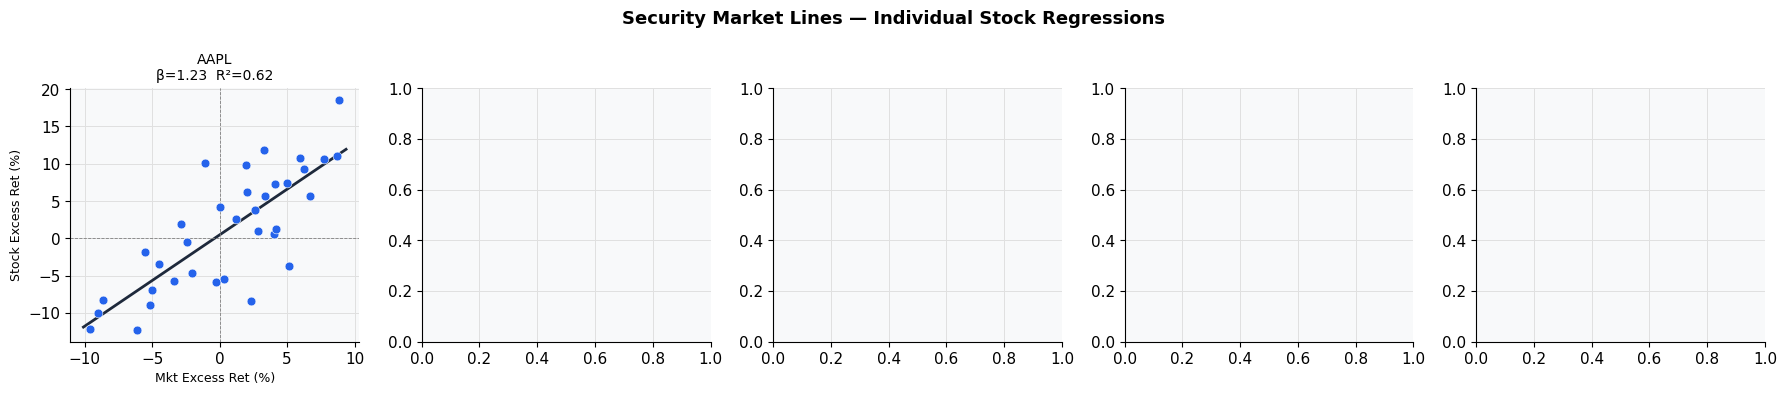

In [85]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig.suptitle("Security Market Lines — Individual Stock Regressions", fontsize=13, fontweight='bold')

mkt = market_excess.values * 100
x_line = np.linspace(mkt.min()-0.5, mkt.max()+0.5, 100)

for i, (ticker, ax) in enumerate(zip(tickers_list, axes)):
    r = all_results[ticker]
    stk = excess[ticker].values * 100
    y_line = r['alpha']*100 + r['beta'] * x_line

    ax.scatter(mkt, stk, color=COLORS[i], s=40, zorder=5, edgecolors='white', lw=0.4)
    ax.plot(x_line, y_line, color='#1e293b', lw=2)
    ax.axhline(0, color='gray', lw=0.6, ls='--')
    ax.axvline(0, color='gray', lw=0.6, ls='--')
    ax.set_xlabel("Mkt Excess Ret (%)", fontsize=9)
    ax.set_ylabel("Stock Excess Ret (%)", fontsize=9)
    ax.set_title(f"{ticker}\nβ={r['beta']:.2f}  R²={r['r2']:.2f}", fontsize=10)

plt.tight_layout()
# plt.savefig('all_sml.png', dpi=120, bbox_inches='tight')
plt.show()


## 10 · Correlation Heatmap — Returns

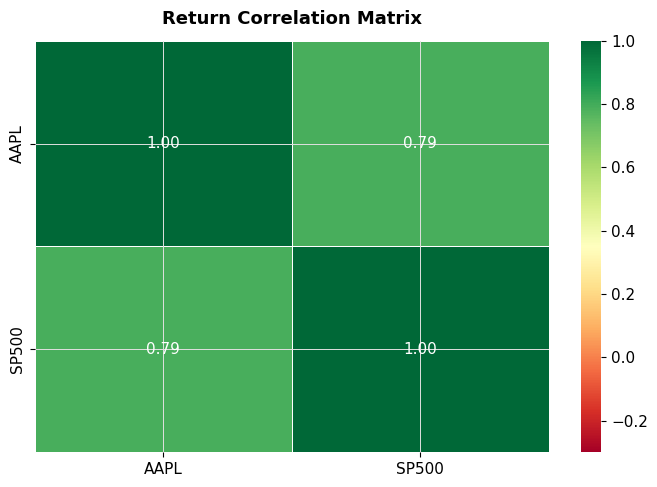


💡 Higher correlation with SP500 → higher R² in CAPM regression


In [86]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = returns[list(TICKERS.keys()) + ['SP500']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-0.3, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})
ax.set_title("Return Correlation Matrix", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
# plt.savefig('correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n💡 Higher correlation with SP500 → higher R² in CAPM regression")


## 11 · How to Scale This Notebook

| Dimension | Change | Where |
|-----------|--------|-------|
| More stocks | Add tickers to `TICKERS` dict | Cell 3 |
| Longer history | Change `START` / `END` | Cell 3 |
| Daily data | Change `interval='1mo'` → `'1d'` | `download_prices()` |
| 3-factor model | Add SMB, HML from Ken French | New cell after Cell 6 |
| Rolling beta | Use `pd.rolling(window).apply(...)` | New cell |
| Different Rf | Change `RF_RATE` | Cell 3 |

### Adding the Fama-French 3-Factor Model (next step)
```python
# Formula:
# R_i - Rf = α + β_mkt*(Rm-Rf) + β_smb*SMB + β_hml*HML + ε
# Download FF factors from: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html
```


## 12 · Key Takeaways

| Concept | What we learned |
|---------|-----------------|
| **Beta (β)** | Measures systematic risk — cannot be diversified away |
| **Alpha (α)** | Excess return not explained by the market; hard to sustain (EMH) |
| **R²** | % of return variation explained by the market factor |
| **p-value** | Is the beta statistically significantly different from zero? |
| **Residuals** | Idiosyncratic (firm-specific) risk — diversifiable |

### Rules of thumb
- β = 0.45 (JNJ) → defensive / low-risk (healthcare, stable cash flows)  
- β = 1.25 (AAPL) → aggressive / high-risk (tech, growth-sensitive)  
- β ≈ 1.0 → moves with the market  
- α not significant → consistent with the **Efficient Market Hypothesis (EMH)**

---
*Built with: yfinance · pandas · statsmodels · matplotlib · seaborn*
